In [1]:
from astropy.io import fits
from src.misc import *
from src.SPECTRUM import Spectrum
from src.FITSPECTRUM import FitSpectrum
from src.DP import DP
import matplotlib.pyplot as plt
import numpy as np
from astropy.table import Table
import pandas as pd

from astropy.coordinates import SkyCoord
from astropy import units as u
from astropy.cosmology import Planck18 as cosmo

In [2]:
DP = DP()
dps_df, model_1comp_dps, left_2comp_dps, right_2comp_dps = DP.extract_fits_data('./catalogs/0315_dps_test.fits')
cs_df, model_1comp_cs, left_2comp_cs, right_2comp_cs = DP.extract_fits_data('./catalogs/0315_nbcs_test.fits')

stellar_df = pd.read_csv('./catalogs/stellar_fits_catalog.csv')
dps_df = pd.merge(dps_df, stellar_df, on='TARGETID', how='left',validate='one_to_one')
cs_df = pd.merge(cs_df, stellar_df, on='TARGETID', how='left',validate='one_to_one')

dps_df.drop(columns=['MORPHTYPE', 'P_VALUE', 'BPT_1COMP'], inplace=True)
cs_df.drop(columns=['MORPHTYPE', 'P_VALUE', 'BPT_2COMP', 'DV_R', 'DV_L', 'SIGMA_L', 'SIGMA_R'], inplace=True)

In [3]:
delta_dv = dps_df['DV_R'] - dps_df['DV_L']
resolution = c * 0.8 / (Halpha_rest*(1+dps_df['Z']))
sigma_r = np.sqrt(dps_df['SIGMA_R']**2 + resolution**2)
sigma_l = np.sqrt(dps_df['SIGMA_L']**2 + resolution**2)
dps_df['delta_dv'] = delta_dv
dps_df['width_ratio'] = sigma_l / sigma_r

# robust_dps = dps_df[(dps_df['BPT_2comp']!=512)&(dps_df['VD_SL']!=0)&(dps_df['LOGM']!=0)]
robust_dps = dps_df[(dps_df['BPT_2COMP']!=512)&(dps_df['LOGM']!=0)]
robust_dps = robust_dps[(~robust_dps['width_ratio'].isnull())]
# robust_cs = cs_df[(cs_df['BPT_1comp']!=256)&(cs_df['VD_SL']!=0)&(cs_df['LOGM']!=0)]
robust_cs = cs_df[(cs_df['BPT_1COMP']!=256)&(cs_df['LOGM']!=0)]

In [4]:
dAGN_dp = robust_dps[robust_dps['BPT_2COMP']==32].copy()
print(len(dAGN_dp))
AGN_cs = robust_cs[robust_cs['BPT_1COMP']==16].copy()
print(len(AGN_cs))

306
570


In [5]:
model_1comp_dps = model_1comp_dps[dAGN_dp.index]
left_2comp_dps = left_2comp_dps[dAGN_dp.index]
right_2comp_dps = right_2comp_dps[dAGN_dp.index]
print(len(model_1comp_dps), len(left_2comp_dps), len(right_2comp_dps))


model_1comp_cs = model_1comp_cs[AGN_cs.index]
print(len(model_1comp_cs))

306 306 306
570


In [28]:
dAGN_dp['flux_ratio'] = [0] * len(dAGN_dp)

flux_ratio = []
for i in range(len(dAGN_dp)):
    flux_ratio.append(dAGN_dp['OIII5007_FLUX_2COMP_L'].iloc[i] / dAGN_dp['OIII5007_FLUX_2COMP_R'].iloc[i])
dAGN_dp['flux_ratio'] = flux_ratio


In [29]:
dAGN_dp = dAGN_dp[dAGN_dp['flux_ratio']!=0].copy()
print(len(dAGN_dp))

306


In [30]:
x = np.linspace(0.1, 10, 100)
y = 0.005-(0.96*np.log10(x))

In [31]:
from scipy import stats

data_x = np.log10(-dAGN_dp['DV_L']/dAGN_dp['DV_R'])
data_y = np.log10(dAGN_dp['flux_ratio'])

# remove NaN and inf values
valid_indices = np.isfinite(data_x) & np.isfinite(data_y) & (data_x > np.log10(0.1)) & (data_x < np.log10(10)) & (data_y > np.log10(0.1)) & (data_y < np.log10(10))
x_fit = data_x[valid_indices]
y_fit = data_y[valid_indices]

# linear fit
slope, intercept, r_value, p_value, std_err = stats.linregress(x_fit, y_fit)

print(f"Slope: {slope}")
print(f"Intercept: {intercept}")
print(f"R-squared: {r_value**2}")

fit_x_range = np.linspace(0.1, 10, 100)
fit_y_values = slope * np.log10(fit_x_range) + intercept
print(p_value)


Slope: -0.4659343760146495
Intercept: 0.018611085948055738
R-squared: 0.20198522186561774
1.7512242137928834e-13


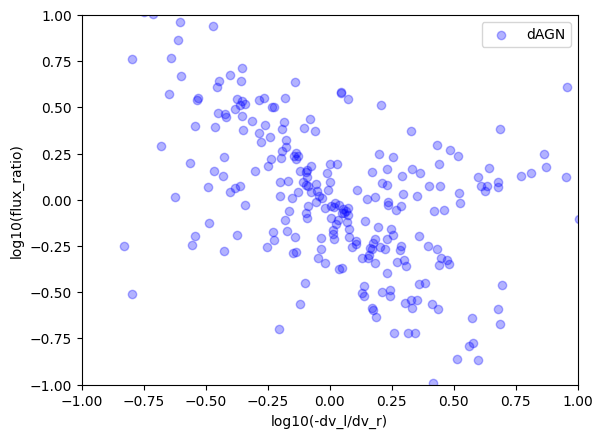

In [32]:
plt.scatter(data_x, data_y, alpha=0.3, color='blue', label='dAGN')
plt.xlabel('log10(-dv_l/dv_r)')
plt.ylabel('log10(flux_ratio)')
plt.xlim(np.log10(0.1), np.log10(10))
plt.ylim(np.log10(0.1), np.log10(10))
plt.legend()
plt.show()

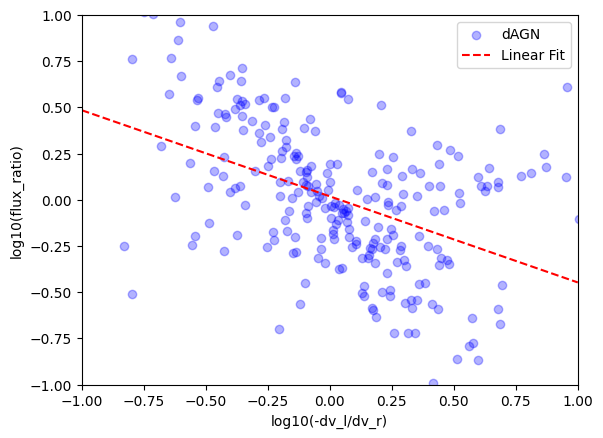

In [33]:
plt.scatter(data_x, data_y, alpha=0.3, color='blue', label='dAGN')
plt.plot(np.log10(fit_x_range), fit_y_values, color='r', linestyle='--', label='Linear Fit')
plt.xlabel('log10(-dv_l/dv_r)')
plt.ylabel('log10(flux_ratio)')
plt.xlim(np.log10(0.1), np.log10(10))
plt.ylim(np.log10(0.1), np.log10(10))
plt.legend()
plt.show()

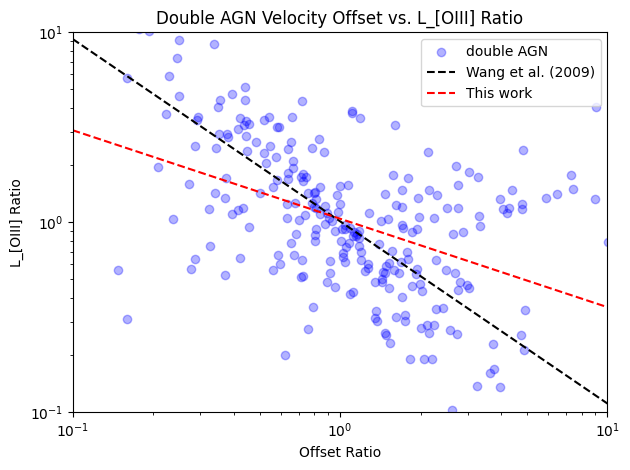

In [34]:
plt.scatter(-dAGN_dp['DV_L']/dAGN_dp['DV_R'], dAGN_dp['flux_ratio'], alpha=0.3, color='blue', label='double AGN')
plt.plot(x, 10**y, color='k', label='Wang et al. (2009)', linestyle='--')
plt.plot(fit_x_range, 10**fit_y_values, color='r', linestyle='--', label='This work')
plt.xscale('log')
plt.yscale('log')
plt.xlim(left=0.1, right=10)
plt.ylim(bottom=0.1, top=10)
plt.xlabel('Offset Ratio')
plt.ylabel('L_[OIII] Ratio')
plt.title('Double AGN Velocity Offset vs. L_[OIII] Ratio')
plt.legend()
plt.tight_layout()
# plt.savefig('./figures/Feb25/dAGN_flux_ratio.png')
plt.show()